In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("/Users/sahilgulati/Desktop/Energy-Usage-Clustering-for-Cooling-Optimization/data/simulated_rack_data.csv", parse_dates=['timestamp'])
df.head()

,timestamp,rack_id,energy_watts,temperature_c
0,2025-07-01 13:57:55.754442,rack_1,369.732899,27.514750
1,2025-07-01 14:12:55.754442,rack_1,359.992365,24.120781
2,2025-07-01 14:27:55.754442,rack_1,366.284848,23.783859
3,2025-07-01 14:42:55.754442,rack_1,354.427539,25.996692
4,2025-07-01 14:57:55.754442,rack_1,363.197060,25.540596


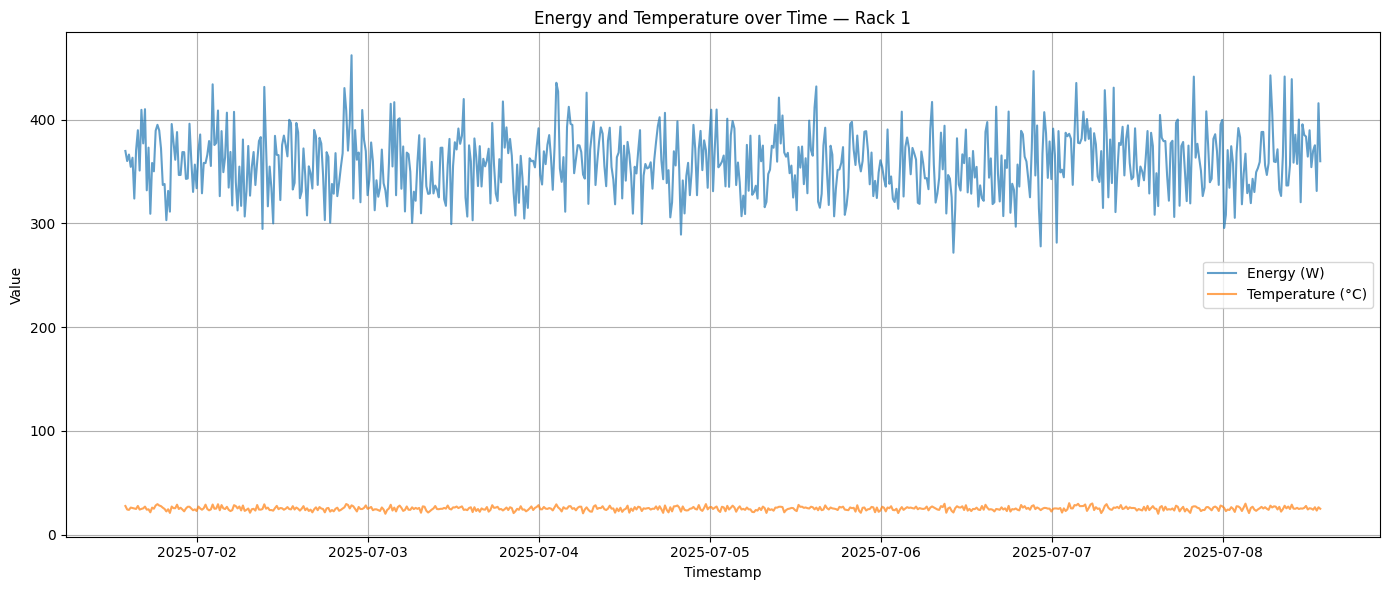

In [51]:
#filtering data just for rack 1
rack_sample = df[df['rack_id']=="rack_1"]
plt.figure(figsize=(14,6))
plt.plot(rack_sample['timestamp'], rack_sample['energy_watts'], label='Energy (W)', alpha=0.7)
plt.plot(rack_sample['timestamp'], rack_sample['temperature_c'], label='Temperature (°C)', alpha=0.7)
plt.title("Energy and Temperature over Time — Rack 1")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler

# Group the data to get the mean energy and temperature per rack
rack_features = df.groupby('rack_id')[['energy_watts', 'temperature_c']].mean().reset_index()

# Save rack_id separately for labeling after clustering
rack_ids = rack_features['rack_id']

# Normalize the features using z-score normalization (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rack_features[['energy_watts', 'temperature_c']])


<Axes: >

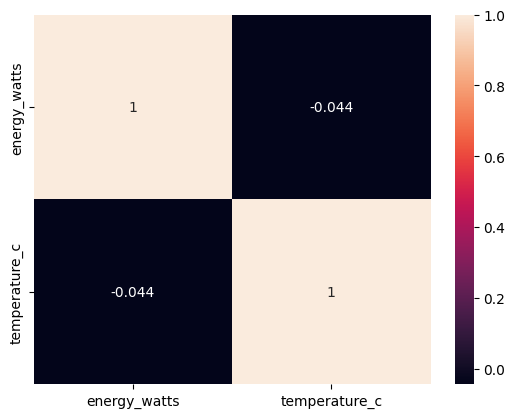

In [43]:
sns.heatmap(rack_features[['energy_watts', 'temperature_c']].corr(), annot=True)

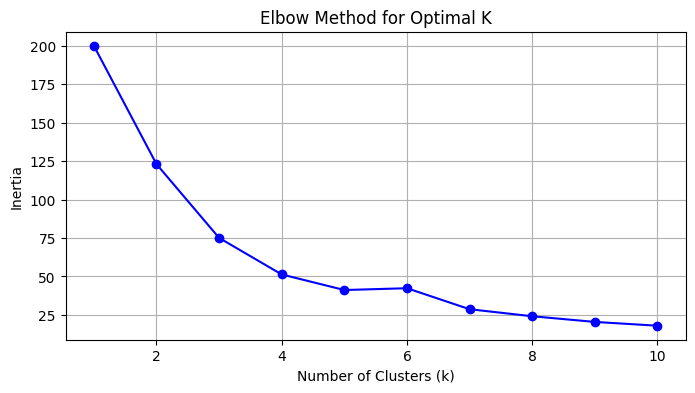

In [44]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1,11)

for k in K_range:
    Kmeans = KMeans(n_clusters = k, random_state=42)
    Kmeans.fit(X_scaled)
    inertia.append(Kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [45]:
K_optimal = 4
Kmeans = KMeans(n_clusters=K_optimal, random_state=42)
clusters = Kmeans.fit_predict(X_scaled)

rack_features['clusters'] = clusters

In [46]:
rack_features['cluster_name'] = rack_features['clusters'].map({
    0: 'High Energy & High Temp',
    1: 'Low Usage / Idle',
    2: 'Normal',
    3: 'Efficient Cooling'
})

In [47]:
rack_features['recommendation'] = rack_features['cluster_name'].map({
    'High Energy & High Temp': 'Check cooling or rebalance load',
    'Low Usage / Idle': ' Possibly power-save or decommission',
    'Normal': 'Operating normally',
    'Efficient Cooling': 'Consider design for other racks'
})


In [48]:
print(rack_features)

     rack_id  energy_watts  temperature_c  clusters             cluster_name  \
0     rack_1    358.568222      25.082718         0  High Energy & High Temp   
1    rack_10    316.909256      33.603314         2                   Normal   
2   rack_100    397.732317      30.918528         3        Efficient Cooling   
3    rack_11    284.307388      31.162346         2                   Normal   
4    rack_12    358.275965      34.170090         3        Efficient Cooling   
..       ...           ...            ...       ...                      ...   
95   rack_95    328.612103      28.512913         0  High Energy & High Temp   
96   rack_96    345.313833      27.162797         0  High Energy & High Temp   
97   rack_97    398.832535      27.969536         0  High Energy & High Temp   
98   rack_98    318.658812      28.436538         0  High Energy & High Temp   
99   rack_99    331.612820      32.985962         3        Efficient Cooling   

                     recommendation  
0